# Importing Libraries

In [1]:
import joblib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:

returns = joblib.load("Returns.pkl")
data = joblib.load("data.pkl")

### Naive Expected Returns

The expected annual return for each asset was estimated using the historical average daily returns. Daily returns were first computed from the adjusted closing prices, and the mean daily return was then annualized by multiplying it by **252**, representing the approximate number of trading days in a year. This approach, known as the **naive expected return** method, assumes that future returns will be similar to historical average returns. The resulting annualized expected returns were used as the expected return inputs for the Modern Portfolio Theory (MPT) portfolio optimization process.

In [3]:

naive_expected_returns = returns.mean() * 252
print("Naive annualized mean return:\n", naive_expected_returns)
print("\nNaive annualized mean return (%):\n", naive_expected_returns * 100)

Naive annualized mean return:
 Ticker
BTC-USD    0.739037
OPGSX      0.201863
VBTLX      0.019300
VDE        0.090412
VGSLX      0.068594
VTIAX      0.083475
VTSAX      0.139102
dtype: float64

Naive annualized mean return (%):
 Ticker
BTC-USD    73.903654
OPGSX      20.186272
VBTLX       1.929975
VDE         9.041235
VGSLX       6.859431
VTIAX       8.347549
VTSAX      13.910153
dtype: float64


### Compound Annual Growth Rate (CAGR)

The expected annual returns were also estimated using the **Compound Annual Growth Rate (CAGR)**, which measures the average annual growth rate of an investment over the entire analysis period while accounting for the compounding effect. First, the adjusted closing prices of all assets were aligned to a common trading-day window by removing missing values. The total number of years covered by the dataset was then calculated, and the CAGR for each asset was computed using its initial and final closing prices. The resulting CAGR values were reindexed to match the order of the return matrix and saved for use in the portfolio optimization process. A bar chart was also generated to compare the annualized expected returns of all assets.


Years spanned (common trading-day window): 10.99

CAGR (expected returns):
 Ticker
BTC-USD    0.670014
OPGSX      0.159966
VBTLX      0.018237
VDE        0.046660
VGSLX      0.048045
VTIAX      0.073242
VTSAX      0.129912
dtype: float64

CAGR (%):
 Ticker
BTC-USD    67.001443
OPGSX      15.996610
VBTLX       1.823678
VDE         4.666002
VGSLX       4.804471
VTIAX       7.324226
VTSAX      12.991186
dtype: float64


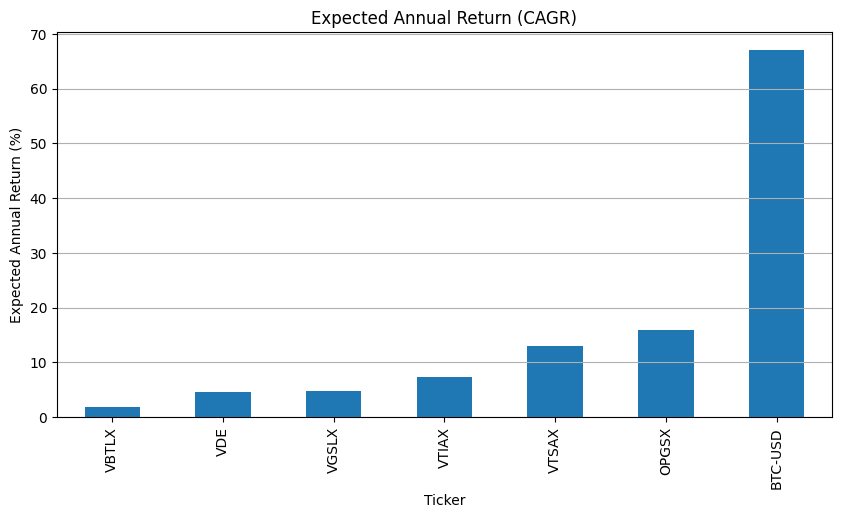

In [ ]:

close_price = data["Close"].dropna()  # aligns all assets to common trading days

years = (close_price.index[-1] - close_price.index[0]).days / 365.25
print(f"\nYears spanned (common trading-day window): {years:.2f}")

cagr = (close_price.iloc[-1] / close_price.iloc[0]) ** (1 / years) - 1


cagr = cagr.reindex(returns.columns)

print("\nCAGR (expected returns):\n", cagr)
print("\nCAGR (%):\n", cagr * 100)

joblib.dump(cagr, "Expected_Returns.pkl")

plt.figure(figsize=(10, 5))
(cagr * 100).sort_values().plot(kind="bar")
plt.ylabel("Expected Annual Return (%)")
plt.title("Expected Annual Return (CAGR)")
plt.grid(axis="y")
plt.show()

### Annualized Covariance Matrix

The covariance matrix was computed from the daily asset returns to measure the relationship between the returns of different assets. Since the returns were calculated on a daily basis, the covariance matrix was annualized by multiplying it by **252**, representing the approximate number of trading days in a year. The annualized covariance matrix was then reordered to match the column order of the return matrix, ensuring consistency during portfolio optimization. A heatmap of the covariance matrix was generated to visualize the covariance between asset pairs, where positive covariance indicates that two assets tend to move in the same direction, while lower or negative covariance suggests diversification benefits. The annualized covariance matrix was subsequently saved for use in the Modern Portfolio Theory (MPT) optimization process.


Annualized covariance matrix shape: (7, 7)


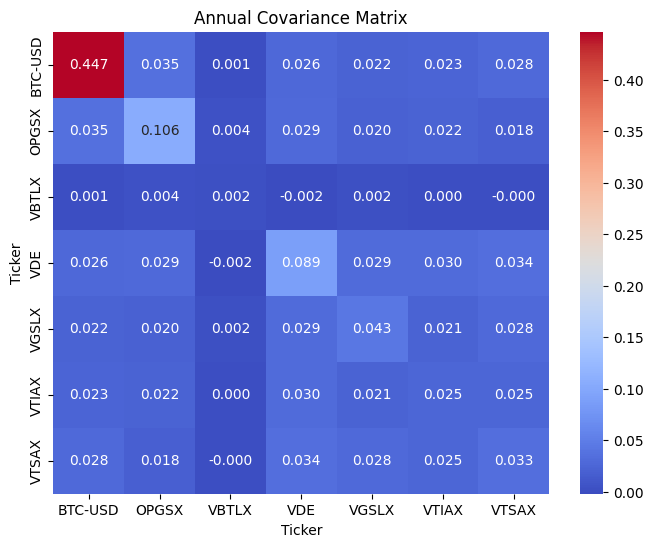

['Covariance.pkl']

In [5]:

cov_matrix_daily = returns.cov()
cov_matrix = (
    returns.cov() * 252
).reindex(
    index=returns.columns,
    columns=returns.columns
)
print("\nAnnualized covariance matrix shape:", cov_matrix.shape)

plt.figure(figsize=(8, 6))
sns.heatmap(cov_matrix, annot=True, cmap="coolwarm", fmt=".3f")
plt.title("Annual Covariance Matrix")
plt.show()

joblib.dump(cov_matrix, "Covariance.pkl")

### Portfolio Performance Evaluation

The generated portfolio allocations were evaluated using the estimated expected returns and the annualized covariance matrix. The expected annual return of each portfolio was calculated as the weighted sum of the expected returns of the individual assets, while the portfolio volatility was computed using the annualized covariance matrix to quantify the overall investment risk. The Sharpe Ratio was then calculated by comparing the portfolio's excess return over the assumed **6% risk-free rate** to its volatility, providing a measure of risk-adjusted performance. These metrics, namely **Expected Return**, **Portfolio Volatility**, and **Sharpe Ratio**, were appended to the portfolio dataset and saved for subsequent portfolio optimization and efficient frontier analysis.

In [6]:

portfolio_data = joblib.load("portfolio_data.pkl")
expected_returns = joblib.load("Expected_Returns.pkl")
cov_matrix = joblib.load("Covariance.pkl")

# Assumption: fixed 6% risk-free rate for reproducibility (see Assumptions section).
# Approximates recent short-term T-bill yields rather than a live-pulled rate.
risk_free_rate = 0.06


expected_returns_arr = expected_returns[returns.columns].values  # enforce order
cov_matrix_arr = cov_matrix.values
weights_matrix = portfolio_data[returns.columns].values  # shape: (n_portfolios, n_assets)

port_returns = weights_matrix @ expected_returns_arr
port_vols = np.sqrt(
    np.einsum("ij,jk,ik->i", weights_matrix, cov_matrix_arr, weights_matrix)
)
port_sharpes = (port_returns - risk_free_rate) / port_vols

portfolio_data["Expected_Return"] = port_returns
portfolio_data["Portfolio_Volatility"] = port_vols
portfolio_data["Sharpe_Ratio"] = port_sharpes

print(portfolio_data.head())

joblib.dump(portfolio_data, "portfolio_data_optimized.pkl")

Ticker   BTC-USD     OPGSX     VBTLX       VDE     VGSLX     VTIAX     VTSAX  \
0       0.038260  0.094371  0.068007  0.484369  0.042025  0.122006  0.150963   
1       0.094819  0.076806  0.058109  0.093447  0.161409  0.361310  0.154100   
2       0.090654  0.172981  0.278093  0.163983  0.031532  0.212984  0.049772   
3       0.025827  0.015625  0.001488  0.418204  0.031454  0.057249  0.450154   
4       0.047786  0.187009  0.055847  0.027544  0.042493  0.321089  0.318233   

Ticker  Volatility Risk_category  Expected_Return  Portfolio_Volatility  \
0         0.201017          High         0.095139              0.201017   
1         0.166520      Moderate         0.135474              0.166520   
2         0.147172        Medium         0.124714              0.147172   
3         0.204879          High         0.103529              0.204879   
4         0.161963      Moderate         0.131137              0.161963   

Ticker  Sharpe_Ratio  
0           0.174806  
1           0.453244  

['portfolio_data_optimized.pkl']